In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# DATA_DIR = Path('data/processed')
# CHARTS_DIR = Path('reports/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading Star Schema data...")

# 1. Load the Fact and Dim tables (without forcing parse_dates yet to avoid errors)
fact_df = pd.read_csv(r'C:\Users\dheer\OneDrive\Desktop\bluestock_data\bluestock_mf_capstone\data\processed\fact_nav_clean.csv')
dim_df = pd.read_csv(r'C:\Users\dheer\OneDrive\Desktop\bluestock_data\bluestock_mf_capstone\data\processed\dim_fund_clean.csv')

# 2. Automatically find the date column (whether it's 'date', 'date_key', or 'calendar_date')
date_col = [col for col in fact_df.columns if 'date' in col.lower()][0]
fact_df[date_col] = pd.to_datetime(fact_df[date_col])

# 3. Merge the tables so we have the actual 'scheme_name' for our charts
# Assuming they connect on 'scheme_code' or similar ID
id_col = [col for col in fact_df.columns if 'code' in col.lower() or 'id' in col.lower()][0]
df = pd.merge(fact_df, dim_df, on=id_col, how='inner')

# 4. Find the NAV column
nav_col = [col for col in df.columns if 'nav' in col.lower()][0]
df[nav_col] = pd.to_numeric(df[nav_col], errors='coerce')

# 5. Pivot the table and forward-fill missing weekend/holiday data
# We'll use the dynamically found date and nav columns, and look for a 'name' column for the funds
name_col = [col for col in df.columns if 'name' in col.lower()][0]

df_nav_pivot = df.pivot_table(index=date_col, columns=name_col, values=nav_col)
df_nav_pivot = df_nav_pivot.ffill()

# 6. Calculate daily percentage change, dropping only completely empty rows
daily_returns = df_nav_pivot.pct_change().dropna(how='all')

print(f"Success! Data loaded. Found {len(daily_returns.columns)} funds over {len(daily_returns)} trading days.")

Loading Star Schema data...
Success! Data loaded. Found 40 funds over 1607 trading days.


## 1. Calculate 95% Historical Value at Risk (VaR)
Value at Risk quantifies the maximum expected daily loss under normal market conditions. We isolate the 5th percentile of daily returns for each fund.


In [9]:
print("Calculating 95% Historical VaR...")

def calculate_var(returns, confidence_level=0.05):
    """Returns the threshold where 95% of returns are better, and 5% are worse."""
    return returns.dropna().quantile(confidence_level)

# Apply VaR calculation across all mutual funds
var_results = daily_returns.apply(calculate_var).reset_index()
var_results.columns = ['scheme_name', '95%_VaR']

# Convert to readable percentage
var_results['95%_VaR_formatted'] = (var_results['95%_VaR'] * 100).round(2).astype(str) + '%'

# Display the 5 riskiest funds
print("\nTop 5 Funds with Highest Daily Downside Risk:")
display(var_results.sort_values('95%_VaR').head())

Calculating 95% Historical VaR...

Top 5 Funds with Highest Daily Downside Risk:


,scheme_name,95%_VaR,95%_VaR_formatted
2,ABSL Small Cap Fund - Regular - Growth,-0.023915,-2.39%
6,Axis Small Cap Fund - Regular - Growth,-0.023284,-2.33%
35,SBI Small Cap Fund - Direct Plan - Growth,-0.023155,-2.32%
31,Nippon India Small Cap Fund - Regular - Growth,-0.022810,-2.28%
8,DSP Small Cap Fund - Regular - Growth,-0.021520,-2.15%


## 2. 90-Day Rolling Sharpe Ratio
Standard Sharpe is static. This tracks risk-adjusted performance dynamically to identify funds that maintain stability during market corrections.|

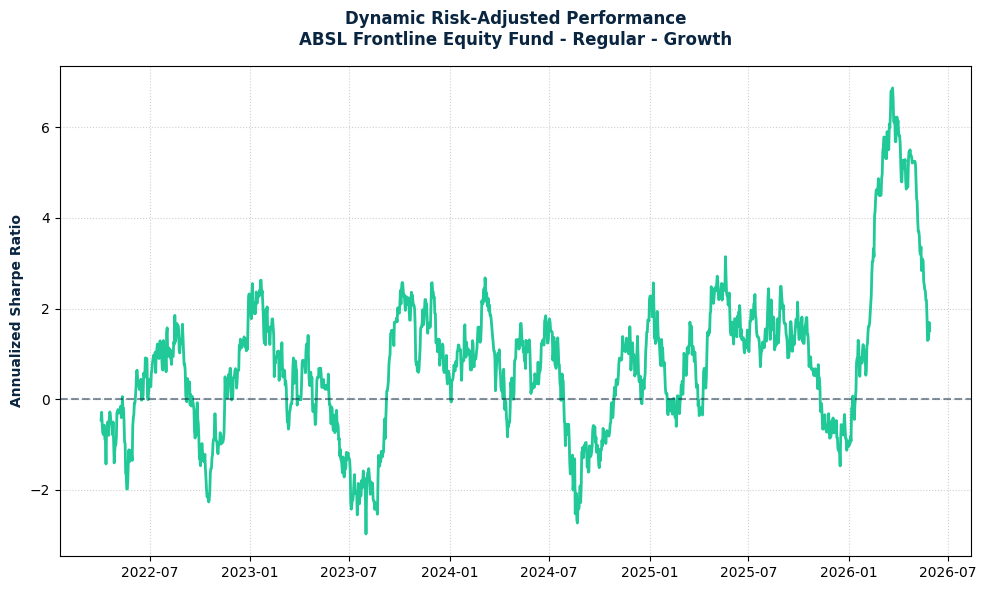

In [13]:
# Define Risk-Free Rate (e.g., 6% annualized)
risk_free_rate_annual = 0.06
risk_free_rate_daily = risk_free_rate_annual / 252

def rolling_sharpe(returns, window=90):
    """Calculates the annualized rolling Sharpe ratio."""
    excess_returns = returns - risk_free_rate_daily
    return (excess_returns.rolling(window).mean() / returns.rolling(window).std()) * np.sqrt(252)

# Select a sample fund to visualize
sample_fund = daily_returns.columns[0] 
rolling_sr = rolling_sharpe(daily_returns[sample_fund])

# Plotting the Chart
plt.figure(figsize=(10, 6))
plt.plot(rolling_sr.index, rolling_sr, color='#20C997', linewidth=2, label='90-Day Sharpe')
plt.axhline(0, color='#0A2540', linestyle='--', alpha=0.5)

plt.title(f'Dynamic Risk-Adjusted Performance\n{sample_fund}', fontweight='bold', pad=15, color='#0A2540')
plt.ylabel('Annualized Sharpe Ratio', fontweight='bold', color='#0A2540')
plt.xlabel('')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'rolling_sharpe_chart.png', dpi=300)
plt.show()

## 3. Daily NAV Return Correlation Matrix
Generates a pairwise correlation matrix to identify overlapping systemic risks between top-performing funds to ensure true diversification.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# DATA_DIR = Path('data/processed')
# CHARTS_DIR = Path('reports/charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading Star Schema data...")

# 1. Load the Fact and Dim tables (without forcing parse_dates yet to avoid errors)
fact_df = pd.read_csv(r'C:\Users\dheer\OneDrive\Desktop\bluestock_data\bluestock_mf_capstone\data\processed\fact_nav_clean.csv')
dim_df = pd.read_csv(r'C:\Users\dheer\OneDrive\Desktop\bluestock_data\bluestock_mf_capstone\data\processed\dim_fund_clean.csv')

# 2. Automatically find the date column (whether it's 'date', 'date_key', or 'calendar_date')
date_col = [col for col in fact_df.columns if 'date' in col.lower()][0]
fact_df[date_col] = pd.to_datetime(fact_df[date_col])

# 3. Merge the tables so we have the actual 'scheme_name' for our charts
# Assuming they connect on 'scheme_code' or similar ID
id_col = [col for col in fact_df.columns if 'code' in col.lower() or 'id' in col.lower()][0]
df = pd.merge(fact_df, dim_df, on=id_col, how='inner')

# 4. Find the NAV column
nav_col = [col for col in df.columns if 'nav' in col.lower()][0]
df[nav_col] = pd.to_numeric(df[nav_col], errors='coerce')

# 5. Pivot the table and forward-fill missing weekend/holiday data
# We'll use the dynamically found date and nav columns, and look for a 'name' column for the funds
name_col = [col for col in df.columns if 'name' in col.lower()][0]

df_nav_pivot = df.pivot_table(index=date_col, columns=name_col, values=nav_col)
df_nav_pivot = df_nav_pivot.ffill()

# 6. Calculate daily percentage change, dropping only completely empty rows
daily_returns = df_nav_pivot.pct_change().dropna(how='all')

print(f"Success! Data loaded. Found {len(daily_returns.columns)} funds over {len(daily_returns)} trading days.")

Loading Star Schema data...
Success! Data loaded. Found 40 funds over 1607 trading days.
